In [1]:
print("Hello to Analysis of zomato business" )

Hello to Analysis of zomato business


### XYZ company wanted to start a restuarant business in bangaluru they are faded with alot of research from various sources from online and connections, in last they are confusioned about the issue so they hire a data scientist to suggest them data driven business solution

metrics : profitable business , consistant customers, pricing strategies   
questions XYZ company wants to arises are:
- which resturantant are most popular?
- which business can generate more profit?
- which region is not much popular?
- how much revenue can be generated from all types of restaurants?
- does region affect restaurant business?
- Is online more perferrable then offline businesses?
- what kind of cusinies do customer most lovable?
- what city is least and most popular?
- Is online booking is more preferred?
- which cusinies are most famous in those regions?
- Which cusinies have more cost per plate?

#### Data Cleaning:

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("zomato.csv")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [5]:
df.isnull().sum()/len(df)*100

url                             0.000000
address                         0.000000
name                            0.000000
online_order                    0.000000
book_table                      0.000000
rate                           15.033741
votes                           0.000000
phone                           2.335789
location                        0.040606
rest_type                       0.438927
dish_liked                     54.291626
cuisines                        0.087012
approx_cost(for two people)     0.669026
reviews_list                    0.000000
menu_item                       0.000000
listed_in(type)                 0.000000
listed_in(city)                 0.000000
dtype: float64

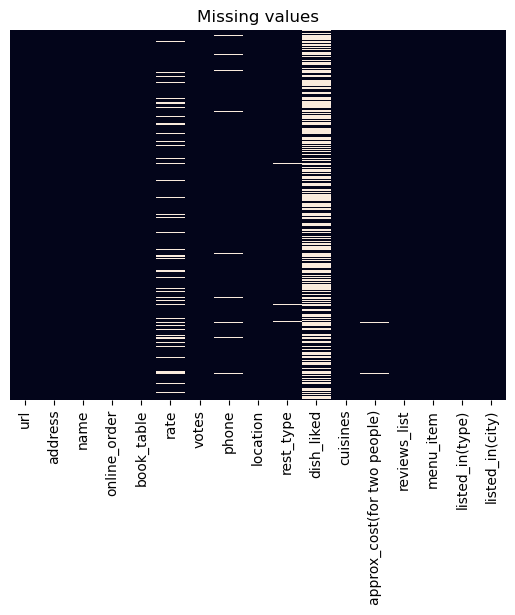

In [6]:
plt.title("Missing values")
sns.heatmap(df.isnull(),yticklabels=False,cbar=False)
plt.show()

##### Removing Irrelevant columns and Null valued columns

In [7]:
columns = ['url','address','phone','dish_liked','menu_item','reviews_list']


df.drop(columns,inplace=True,axis=1)

rate 15.033741322969234
location 0.04060560357329312
rest_type 0.438927238625597
cuisines 0.08701200765705668
approx_cost(for two people) 0.669025658874258



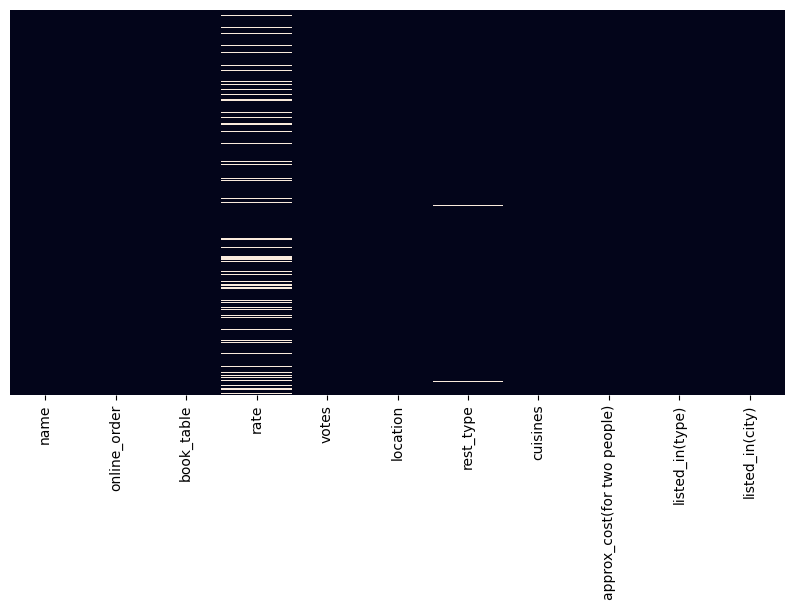

In [8]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),yticklabels=False,cbar=False)
for i in df.columns:
    if df[i].isnull().sum() > 0:
        print(i, (df[i].isnull().sum()/len(df)*100))
print("")
plt.show()

In [9]:
df.columns,df.dtypes

(Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
        'rest_type', 'cuisines', 'approx_cost(for two people)',
        'listed_in(type)', 'listed_in(city)'],
       dtype='object'),
 name                           object
 online_order                   object
 book_table                     object
 rate                           object
 votes                           int64
 location                       object
 rest_type                      object
 cuisines                       object
 approx_cost(for two people)    object
 listed_in(type)                object
 listed_in(city)                object
 dtype: object)

In [10]:
for col in df.select_dtypes('object').columns:
    print("column name:",col)
    print("Number of unique values:",df[col].nunique())
    print("Number of null values:",df[col].isnull().sum())
    print(df[col].unique())
    print("---"*50)

column name: name
Number of unique values: 8792
Number of null values: 0
['Jalsa' 'Spice Elephant' 'San Churro Cafe' ... 'Nawabs Empire'
 'SeeYa Restaurant'
 'Plunge - Sheraton Grand Bengaluru Whitefield Hotel &...']
------------------------------------------------------------------------------------------------------------------------------------------------------
column name: online_order
Number of unique values: 2
Number of null values: 0
['Yes' 'No']
------------------------------------------------------------------------------------------------------------------------------------------------------
column name: book_table
Number of unique values: 2
Number of null values: 0
['Yes' 'No']
------------------------------------------------------------------------------------------------------------------------------------------------------
column name: rate
Number of unique values: 64
Number of null values: 7775
['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3

In [11]:
for col in df.columns:
    if df[col].isnull().sum() >0:
        print(col,df[col].dtypes)

rate object
location object
rest_type object
cuisines object
approx_cost(for two people) object


#### Data Cleaning:

In [12]:
df['rate']

0         4.1/5
1         4.1/5
2         3.8/5
3         3.7/5
4         3.8/5
          ...  
51712    3.6 /5
51713       NaN
51714       NaN
51715    4.3 /5
51716    3.4 /5
Name: rate, Length: 51717, dtype: object

In [13]:
df['rate'].dtype

dtype('O')

In [14]:
'rate' == df.rate.keys

False

In [15]:
df.rate.name

'rate'

In [16]:
def rateformatter(col):
    if col == 'NEW' or col == '-':
        return np.nan
    else:
        return float(str(col).split("/")[0])

In [17]:
df['rate'] = df['rate'].apply(rateformatter)
df.rate.unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [18]:
np.round(df['rate'].mean(),1)

np.float64(3.7)

In [19]:
df['rate'] = df['rate'].fillna(np.round(df['rate'].mean(),1))

In [20]:
df['location']

0                      Banashankari
1                      Banashankari
2                      Banashankari
3                      Banashankari
4                      Basavanagudi
                    ...            
51712                    Whitefield
51713                    Whitefield
51714                    Whitefield
51715    ITPL Main Road, Whitefield
51716    ITPL Main Road, Whitefield
Name: location, Length: 51717, dtype: object

In [21]:
df[df.location.isnull()]

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
1662,Papa Khan Rasoi,No,No,3.7,0,NaN,NaN,NaN,NaN,Delivery,Bannerghatta Road
9874,Papa Khan Rasoi,No,No,3.7,0,NaN,NaN,NaN,NaN,Delivery,BTM
13693,Mohabbat Desi Restaurant,No,No,3.7,0,NaN,NaN,NaN,NaN,Delivery,Electronic City
16351,Desi Chatkara,No,No,3.7,0,NaN,NaN,NaN,NaN,Delivery,HSR
26432,New Taj Biryani Centre,No,No,3.7,0,NaN,NaN,NaN,NaN,Dine-out,Kammanahalli
26519,AB's - Absolute Barbecues,No,No,3.7,0,NaN,NaN,NaN,NaN,Buffet,Koramangala 4th Block
27672,Manchow,No,No,3.7,0,NaN,NaN,NaN,NaN,Delivery,Koramangala 4th Block
28611,Manchow,No,No,3.7,0,NaN,NaN,NaN,NaN,Dine-out,Koramangala 4th Block
29298,AB's - Absolute Barbecues,No,No,3.7,0,NaN,NaN,NaN,NaN,Buffet,Koramangala 5th Block
30604,Manchow,No,No,3.7,0,NaN,NaN,NaN,NaN,Delivery,Koramangala 5th Block


In [22]:
df.location.unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', nan, 'CV Raman Nagar', 'Electronic City', 'HSR',
       'Marathahalli', 'Sarjapur Road', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Koramangala 8th Block', 'Richmond Road',
       'Koramangala 7th Block', 'Jalahalli', 'Koramangala 4th Block',
       'Bellandur', 'Whitefield', 'East Bangalore', 'Old Airport Road',
       'Indiranagar', 'Koramangala 1st Block', 'Frazer Town', 'RT Nagar',
       'MG Road', 'Brigade Road', 'Lavelle Road', 'Church Street',
       'Ulsoor', 'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road',
       'Commercial Street', 'Vasanth Nagar', 'HBR Layout', 'Domlur',
       'Ejipura', 'Jeevan 

In [23]:
df['location'] = df['location'].fillna('Unknown')
df['location'].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', 'Unknown', 'CV Raman Nagar', 'Electronic City',
       'HSR', 'Marathahalli', 'Sarjapur Road', 'Wilson Garden',
       'Shanti Nagar', 'Koramangala 5th Block', 'Koramangala 8th Block',
       'Richmond Road', 'Koramangala 7th Block', 'Jalahalli',
       'Koramangala 4th Block', 'Bellandur', 'Whitefield',
       'East Bangalore', 'Old Airport Road', 'Indiranagar',
       'Koramangala 1st Block', 'Frazer Town', 'RT Nagar', 'MG Road',
       'Brigade Road', 'Lavelle Road', 'Church Street', 'Ulsoor',
       'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road',
       'Commercial Street', 'Vasanth Nagar', 'HBR Layout', 'Domlur',
       'Ejipu

In [24]:
df['rest_type']

0              Casual Dining
1              Casual Dining
2        Cafe, Casual Dining
3                Quick Bites
4              Casual Dining
                ...         
51712                    Bar
51713                    Bar
51714                    Bar
51715                    Bar
51716     Bar, Casual Dining
Name: rest_type, Length: 51717, dtype: object

In [25]:
df['rest_type'].isnull().sum()

np.int64(227)

In [26]:
df[df['rest_type'].isnull()]

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
999,Mughlai Kitchen,Yes,No,3.5,269,BTM,NaN,"Mughlai, North Indian, Chinese, Momos",600,Delivery,Bannerghatta Road
1300,Eat & Joy Restaurant,Yes,No,3.0,7,JP Nagar,NaN,"Fast Food, Finger Food",300,Delivery,Bannerghatta Road
1376,Kababish Restaurant,Yes,No,3.6,15,BTM,NaN,"North Indian, Chinese, Arabian",700,Delivery,Bannerghatta Road
1565,Goli Vada Pav No 1,No,No,3.7,0,Bannerghatta Road,NaN,"Street Food, Burger",150,Delivery,Bannerghatta Road
1637,Ammi's Biryani,No,No,2.4,392,Bannerghatta Road,NaN,"Biryani, North Indian",500,Delivery,Bannerghatta Road
...,...,...,...,...,...,...,...,...,...,...,...
50978,Snack Itt,No,No,3.7,0,Whitefield,NaN,Bakery,200,Desserts,Whitefield
51130,Pindi Bangalore,Yes,No,3.7,0,Whitefield,NaN,"North Indian, Chinese, Biryani, Street Food",900,Dine-out,Whitefield
51195,Special Biryani House,Yes,No,3.2,202,Whitefield,NaN,"North Indian, Biryani, Chinese",400,Dine-out,Whitefield
51294,Red Roost,No,No,3.7,0,Whitefield,NaN,"North Indian, South Indian",500,Dine-out,Whitefield


In [27]:
df['rest_type'].unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Beverage Shop, Quick Bites', 'Confectionery',
       'Quick Bites, Beverage Shop', 'Dessert Parlor, Sweet Shop',
       'Bakery, Quick Bites', 'Sweet Shop, Quick Bites', 'Kiosk',
       'Food Truck', 'Quick Bites, Dessert Parlor',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Dessert Parlor, Quick Bites',
       'Microbrewery, Casual Dining', 'Lounge', 'Bar, Casual Dining',
       'Food Court', 'Cafe, Bakery', nan, 'Dhaba',
       'Quick Bites, Sweet Shop', 'Microbrewery',
       'Food Court, Quick Bites', 'Pub, Bar', 'Casual Dining, Pub',
      

In [28]:
df['rest_type'] = df['rest_type'].fillna('Unknown')

In [29]:
df[df['rest_type'].isnull()]

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)


In [30]:
df['cuisines']

0                North Indian, Mughlai, Chinese
1                   Chinese, North Indian, Thai
2                        Cafe, Mexican, Italian
3                    South Indian, North Indian
4                      North Indian, Rajasthani
                          ...                  
51712                               Continental
51713                               Finger Food
51714                               Finger Food
51715                               Finger Food
51716    Finger Food, North Indian, Continental
Name: cuisines, Length: 51717, dtype: object

In [31]:
df[df['cuisines'].isnull()]

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
438,The House Of Vadapav,Yes,No,3.7,0,Banashankari,Quick Bites,NaN,150,Delivery,Banashankari
440,Lassi Spot,Yes,No,3.3,4,Kumaraswamy Layout,Beverage Shop,NaN,100,Delivery,Banashankari
759,The House Of Vadapav,Yes,No,3.7,0,Banashankari,Quick Bites,NaN,150,Dine-out,Banashankari
1662,Papa Khan Rasoi,No,No,3.7,0,Unknown,Unknown,NaN,NaN,Delivery,Bannerghatta Road
4037,Chai Point,Yes,No,3.7,0,Marathahalli,"Beverage Shop, Quick Bites",NaN,200,Delivery,Bellandur
6887,Noodle Oodle,Yes,No,3.6,9,Whitefield,Delivery,NaN,400,Delivery,Brookefield
6897,Taste of Chettinad,Yes,No,3.7,0,Whitefield,Delivery,NaN,400,Delivery,Brookefield
7277,Watheen Nuts,No,No,3.7,0,Whitefield,"Takeaway, Delivery",NaN,400,Delivery,Brookefield
7555,Delhi Food Factory,Yes,No,3.7,0,Marathahalli,Delivery,NaN,500,Delivery,Brookefield
9874,Papa Khan Rasoi,No,No,3.7,0,Unknown,Unknown,NaN,NaN,Delivery,BTM


In [32]:
df['cuisines'].unique()

array(['North Indian, Mughlai, Chinese', 'Chinese, North Indian, Thai',
       'Cafe, Mexican, Italian', ...,
       'North Indian, Street Food, Biryani', 'Chinese, Mughlai',
       'North Indian, Chinese, Arabian, Momos'],
      shape=(2724,), dtype=object)

In [33]:
df['cuisines'].isnull().sum()

np.int64(45)

In [34]:
df['cuisines'] = df['cuisines'].fillna('Unkown')

In [35]:
df['approx_cost(for two people)']

0          800
1          800
2          800
3          300
4          600
         ...  
51712    1,500
51713      600
51714    2,000
51715    2,500
51716    1,500
Name: approx_cost(for two people), Length: 51717, dtype: object

In [36]:
df['approx_cost(for two people)'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '50', '190', '1,700', nan, '1,400', '180',
       '1,350', '2,200', '2,000', '1,800', '1,900', '330', '2,500',
       '2,100', '3,000', '2,800', '3,400', '40', '1,250', '3,500',
       '4,000', '2,400', '2,600', '120', '1,450', '469', '70', '3,200',
       '60', '560', '240', '360', '6,000', '1,050', '2,300', '4,100',
       '5,000', '3,700', '1,650', '2,700', '4,500', '140'], dtype=object)

In [37]:
float('1,200'.replace(',',''))

1200.0

In [38]:
df['approx_cost(for two people)'].dtype

dtype('O')

In [39]:
df['approx_cost(for two people)']

0          800
1          800
2          800
3          300
4          600
         ...  
51712    1,500
51713      600
51714    2,000
51715    2,500
51716    1,500
Name: approx_cost(for two people), Length: 51717, dtype: object

In [40]:
def costformatter(value):
   return float(str(value).replace(',',''))

In [41]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].apply(costformatter)

In [42]:
df[df['approx_cost(for two people)'].isnull()]

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
1662,Papa Khan Rasoi,No,No,3.7,0,Unknown,Unknown,Unkown,NaN,Delivery,Bannerghatta Road
1768,Innate,No,No,3.7,0,JP Nagar,Delivery,Beverages,NaN,Delivery,Bannerghatta Road
1795,Super Chef's (New Royal treat),No,No,3.7,0,Bannerghatta Road,Quick Bites,"North Indian, Chinese, South Indian",NaN,Delivery,Bannerghatta Road
3069,Super Chef's (New Royal treat),No,No,3.7,0,Bannerghatta Road,Quick Bites,"North Indian, Chinese, South Indian",NaN,Delivery,Basavanagudi
3774,The Hub - Ibis Bengaluru,No,No,3.9,237,Marathahalli,Bar,Finger Food,NaN,Buffet,Bellandur
...,...,...,...,...,...,...,...,...,...,...,...
50940,Cinnabon,No,No,4.0,80,Whitefield,Quick Bites,"Beverages, American, Bakery",NaN,Desserts,Whitefield
51233,Mayas kitchen,No,No,3.7,0,Whitefield,Casual Dining,"South Indian, Chinese, Chettinad",NaN,Dine-out,Whitefield
51247,Mast Kalandar,No,No,2.6,76,Whitefield,Casual Dining,North Indian,NaN,Dine-out,Whitefield
51271,Karavalli Food Court,No,No,3.2,4,Whitefield,Casual Dining,South Indian,NaN,Dine-out,Whitefield


In [43]:
df['approx_cost(for two people)'].unique()

array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199.,   80., 1100.,  160., 1600.,
        230.,  130.,   50.,  190., 1700.,   nan, 1400.,  180., 1350.,
       2200., 2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800.,
       3400.,   40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,
        469.,   70., 3200.,   60.,  560.,  240.,  360., 6000., 1050.,
       2300., 4100., 5000., 3700., 1650., 2700., 4500.,  140.])

In [44]:
df['approx_cost(for two people)'].isnull().sum()

np.int64(346)

In [45]:
df['approx_cost(for two people)'].fillna(np.round(df['approx_cost(for two people)'].mean()),inplace=True)

C:\Users\Galib\AppData\Local\Temp\ipykernel_8736\337693408.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['approx_cost(for two people)'].fillna(np.round(df['approx_cost(for two people)'].mean()),inplace=True)


In [46]:
df['approx_cost(for two people)'].isnull().sum()

np.int64(0)

In [47]:
df['approx_cost(for two people)'].unique()

array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199.,   80., 1100.,  160., 1600.,
        230.,  130.,   50.,  190., 1700.,  555., 1400.,  180., 1350.,
       2200., 2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800.,
       3400.,   40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,
        469.,   70., 3200.,   60.,  560.,  240.,  360., 6000., 1050.,
       2300., 4100., 5000., 3700., 1650., 2700., 4500.,  140.])

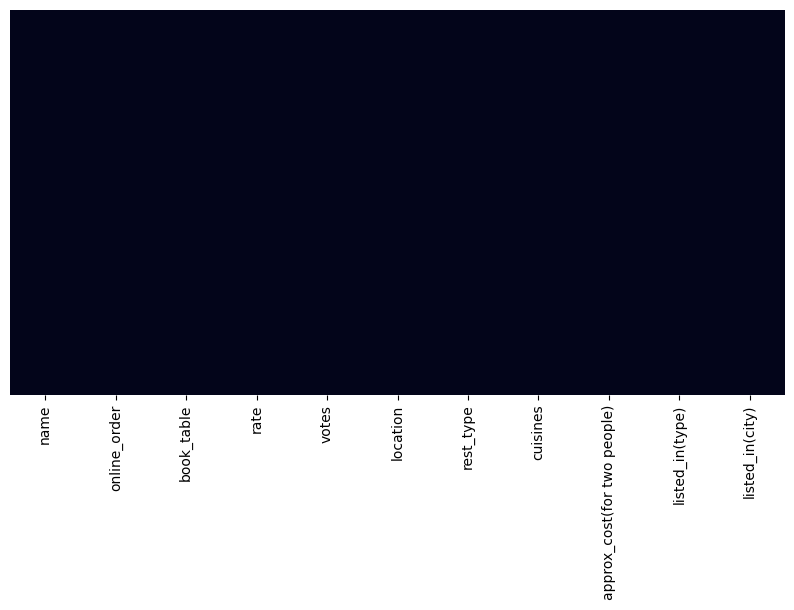

In [48]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),yticklabels=False,cbar=False)
plt.show()

In [49]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
listed_in(city)                0
dtype: int64

In [50]:
# rename and reassess features for eda
# listed cities
df['listed_in(city)'].unique()

array(['Banashankari', 'Bannerghatta Road', 'Basavanagudi', 'Bellandur',
       'Brigade Road', 'Brookefield', 'BTM', 'Church Street',
       'Electronic City', 'Frazer Town', 'HSR', 'Indiranagar',
       'Jayanagar', 'JP Nagar', 'Kalyan Nagar', 'Kammanahalli',
       'Koramangala 4th Block', 'Koramangala 5th Block',
       'Koramangala 6th Block', 'Koramangala 7th Block', 'Lavelle Road',
       'Malleshwaram', 'Marathahalli', 'MG Road', 'New BEL Road',
       'Old Airport Road', 'Rajajinagar', 'Residency Road',
       'Sarjapur Road', 'Whitefield'], dtype=object)

In [51]:
# location 
df['location'].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', 'Unknown', 'CV Raman Nagar', 'Electronic City',
       'HSR', 'Marathahalli', 'Sarjapur Road', 'Wilson Garden',
       'Shanti Nagar', 'Koramangala 5th Block', 'Koramangala 8th Block',
       'Richmond Road', 'Koramangala 7th Block', 'Jalahalli',
       'Koramangala 4th Block', 'Bellandur', 'Whitefield',
       'East Bangalore', 'Old Airport Road', 'Indiranagar',
       'Koramangala 1st Block', 'Frazer Town', 'RT Nagar', 'MG Road',
       'Brigade Road', 'Lavelle Road', 'Church Street', 'Ulsoor',
       'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road',
       'Commercial Street', 'Vasanth Nagar', 'HBR Layout', 'Domlur',
       'Ejipu

#### Data Engneering , Analysis and Visualization

In [52]:
df

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,Continental,1500.0,Pubs and bars,Whitefield
51713,Vinod Bar And Restaurant,No,No,3.7,0,Whitefield,Bar,Finger Food,600.0,Pubs and bars,Whitefield
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.7,0,Whitefield,Bar,Finger Food,2000.0,Pubs and bars,Whitefield
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,Finger Food,2500.0,Pubs and bars,Whitefield


In [53]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost(for two people)',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [54]:
df1 = df.rename({'name':'restaurant_name','online_order':'online_order','book_table':'book_table','votes':'votes','location':'location','rest_type':'restaurant_type','cuisines':'cuisines','approx_cost(for two people)':'cost2people','listed_in(type)':'listed_in_type','listed_in(city)':'listed_in_city'},axis=1)
df1.head()

,restaurant_name,online_order,book_table,rate,votes,location,restaurant_type,cuisines,cost2people,listed_in_type,listed_in_city
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari


In [55]:
df1.select_dtypes(['int','float']).describe()

,rate,votes,cost2people
count,51717.000000,51717.000000,51717.000000
mean,3.700362,283.697527,555.428679
std,0.395391,803.838853,437.380225
min,1.800000,0.000000,40.000000
25%,3.500000,7.000000,300.000000
50%,3.700000,41.000000,400.000000
75%,3.900000,198.000000,650.000000
max,4.900000,16832.000000,6000.000000


In [56]:
df1.select_dtypes('object').describe()

,restaurant_name,online_order,book_table,location,restaurant_type,cuisines,listed_in_type,listed_in_city
count,51717,51717,51717,51717,51717,51717,51717,51717
unique,8792,2,2,94,94,2724,7,30
top,Cafe Coffee Day,Yes,No,BTM,Quick Bites,North Indian,Delivery,BTM
freq,96,30444,45268,5124,19132,2913,25942,3279


In [57]:
df1.duplicated().sum()

np.int64(108)

In [58]:
df1[df1.duplicated()]

,restaurant_name,online_order,book_table,rate,votes,location,restaurant_type,cuisines,cost2people,listed_in_type,listed_in_city
596,My Tea House,Yes,Yes,3.7,0,Banashankari,Casual Dining,"Continental, Asian, North Indian, Tea",500.0,Dine-out,Banashankari
2235,Shiv Sagar,No,No,3.6,10,Bannerghatta Road,Food Court,"South Indian, Beverages",400.0,Dine-out,Bannerghatta Road
3763,The Fisherman's Wharf,Yes,Yes,4.4,4099,Sarjapur Road,"Casual Dining, Bar","Seafood, Goan, North Indian, Continental, Asian",1400.0,Buffet,Bellandur
4339,Biryani Treat,No,No,3.7,0,Bellandur,Quick Bites,Biryani,400.0,Delivery,Bellandur
4949,OPUS Club,No,Yes,4.4,1496,Sarjapur Road,Pub,"Continental, Italian, North Indian, Mexican",1900.0,Drinks & nightlife,Bellandur
...,...,...,...,...,...,...,...,...,...,...,...
49193,Sri Ganesh Juice Junction,Yes,No,3.5,6,Bellandur,Beverage Shop,"Juices, Fast Food",200.0,Delivery,Sarjapur Road
49432,Biryani Treat,No,No,3.7,0,Bellandur,Quick Bites,Biryani,400.0,Delivery,Sarjapur Road
50379,House Of Candy,Yes,No,3.7,0,Whitefield,Confectionery,Desserts,200.0,Delivery,Whitefield
50405,House Of Candy,Yes,No,3.7,0,Whitefield,Confectionery,Desserts,200.0,Delivery,Whitefield


In [59]:
df1.columns

Index(['restaurant_name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'restaurant_type', 'cuisines', 'cost2people',
       'listed_in_type', 'listed_in_city'],
      dtype='object')

In [60]:
duplicated = df1.duplicated(subset=['restaurant_name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'restaurant_type', 'cuisines', 'cost2people',
       'listed_in_type', 'listed_in_city'])

print(duplicated.any())

True


In [61]:
duplicate_rest_name = df1[df1['restaurant_name']=="Biryani Treat"].duplicated().index
list_return = [x[0] if x[1] == True else "" for x in zip(df1.iloc[duplicate_rest_name].duplicated().index,df1.iloc[duplicate_rest_name].duplicated())]
duplicated_idx = []
for i in list_return:
    if i == '':
        continue
    else:
        print(i)
        duplicated_idx.append(i)
#print([x[0] if x[1] == True else "" for x in zip(df1.iloc[duplicate_rest_name].duplicated().index,df1.iloc[duplicate_rest_name].duplicated())])
print(df1.iloc[duplicated_idx])
df1.iloc[duplicate_rest_name]

4339
49432
      restaurant_name online_order book_table  rate  votes   location  \
4339    Biryani Treat           No         No   3.7      0  Bellandur   
49432   Biryani Treat           No         No   3.7      0  Bellandur   

      restaurant_type cuisines  cost2people listed_in_type listed_in_city  
4339      Quick Bites  Biryani        400.0       Delivery      Bellandur  
49432     Quick Bites  Biryani        400.0       Delivery  Sarjapur Road  


,restaurant_name,online_order,book_table,rate,votes,location,restaurant_type,cuisines,cost2people,listed_in_type,listed_in_city
1766,Biryani Treat,No,No,3.7,0,JP Nagar,"Takeaway, Delivery",Biryani,400.0,Delivery,Bannerghatta Road
4338,Biryani Treat,No,No,3.7,0,Bellandur,Quick Bites,Biryani,400.0,Delivery,Bellandur
4339,Biryani Treat,No,No,3.7,0,Bellandur,Quick Bites,Biryani,400.0,Delivery,Bellandur
4422,Biryani Treat,No,No,3.7,0,Sarjapur Road,"Takeaway, Delivery",Biryani,400.0,Delivery,Bellandur
4782,Biryani Treat,No,No,3.7,0,Bellandur,Quick Bites,Biryani,400.0,Dine-out,Bellandur
18236,Biryani Treat,No,No,3.7,0,Indiranagar,"Takeaway, Delivery",Biryani,400.0,Delivery,Indiranagar
20773,Biryani Treat,No,No,3.7,0,JP Nagar,"Takeaway, Delivery",Biryani,400.0,Delivery,Jayanagar
22627,Biryani Treat,No,No,3.7,0,JP Nagar,"Takeaway, Delivery",Biryani,400.0,Delivery,JP Nagar
39951,Biryani Treat,No,No,3.7,0,Rajajinagar,Quick Bites,Biryani,400.0,Delivery,Malleshwaram
40390,Biryani Treat,No,No,3.7,0,Rajajinagar,Quick Bites,Biryani,400.0,Dine-out,Malleshwaram


In [62]:
def drop_duplicates(rest_name):
    duplicate_rest_name = df1[df1['restaurant_name']==rest_name].duplicated().index
    return duplicate_rest_name;

In [63]:
duplicated_idx = []
for name in df1['restaurant_name'].unique():
    duplicate_rest_name = df1[df1['restaurant_name']==name].duplicated().index
    list_return = [x[0] if x[1] == True else "" for x in zip(df1.iloc[duplicate_rest_name].duplicated().index,df1.iloc[duplicate_rest_name].duplicated())]
    
    for i in list_return:
        if i == '':
            continue
        else:
            print(i)
            duplicated_idx.append(i)


596
12300
12332
12354
19861
38109
20236
9467
9464
9470
2235
23583
12306
39674
46553
50379
50405
4339
49432
20852
20853
12288
12290
12347
9471
42343
24576
3763
46065
4950
4969
49193
4949
38585
43369
37692
12338
12296
12330
17655
42312
12343
12328
12305
12294
12312
12339
12350
12295
12351
12286
12304
12329
12289
12287
12314
12293
12291
12355
12348
12292
6609
43354
12322
43850
48777
7599
50904
20836
12335
31306
29015
31744
34483
37216
9342
10711
30570
36097
37354
9549
9638
9465
9466
9468
9469
16836
28139
20851
11503
31087
12342
12303
13442
13467
18715
46118
18660
18654
46066
26434
24569
24554
25109
25864
26402
41563
41404


In [64]:
df1.iloc[duplicated_idx]

,restaurant_name,online_order,book_table,rate,votes,location,restaurant_type,cuisines,cost2people,listed_in_type,listed_in_city
596,My Tea House,Yes,Yes,3.7,0,Banashankari,Casual Dining,"Continental, Asian, North Indian, Tea",500.0,Dine-out,Banashankari
12300,Corner House Ice Cream,Yes,No,4.4,635,Residency Road,Dessert Parlor,"Ice Cream, Desserts",400.0,Delivery,Church Street
12332,Vietnamese Kitchen,Yes,Yes,4.1,525,Indiranagar,Casual Dining,"Chinese, Vietnamese, Momos, Thai",800.0,Delivery,Church Street
12354,Toscano,Yes,Yes,4.4,1842,Lavelle Road,Casual Dining,"Italian, Salad",1500.0,Delivery,Church Street
19861,Toscano,Yes,Yes,4.5,715,Koramangala 7th Block,Casual Dining,"Italian, Salad",1500.0,Delivery,Jayanagar
...,...,...,...,...,...,...,...,...,...,...,...
25109,Delish Chinese Fast Food,Yes,No,3.2,4,Banaswadi,Quick Bites,"Chinese, North Indian, Biryani",300.0,Dine-out,Kalyan Nagar
25864,Delish Chinese Fast Food,Yes,No,3.2,4,Banaswadi,Quick Bites,"Chinese, North Indian, Biryani",300.0,Delivery,Kammanahalli
26402,Delish Chinese Fast Food,Yes,No,3.2,4,Banaswadi,Quick Bites,"Chinese, North Indian, Biryani",300.0,Dine-out,Kammanahalli
41563,Sizzling Pasto,Yes,Yes,4.1,99,Marathahalli,"Casual Dining, Bar","Continental, Chinese, North Indian",1100.0,Dine-out,Marathahalli


In [65]:
df2  = df1.drop_duplicates()

In [66]:
df2.duplicated().any()

np.False_

restaurant_name
Cafe Coffee Day      96
Onesta               85
Just Bake            73
Empire Restaurant    71
Five Star Chicken    70
Kanti Sweets         68
Petoo                66
Polar Bear           65
Baskin Robbins       64
Chef Baker's         62
Pizza Hut            62
Subway               60
KFC                  60
Sweet Truth          60
Domino's Pizza       60
Beijing Bites        60
McDonald's           59
Smoor                59
Chai Point           58
Faasos               57
Name: count, dtype: int64


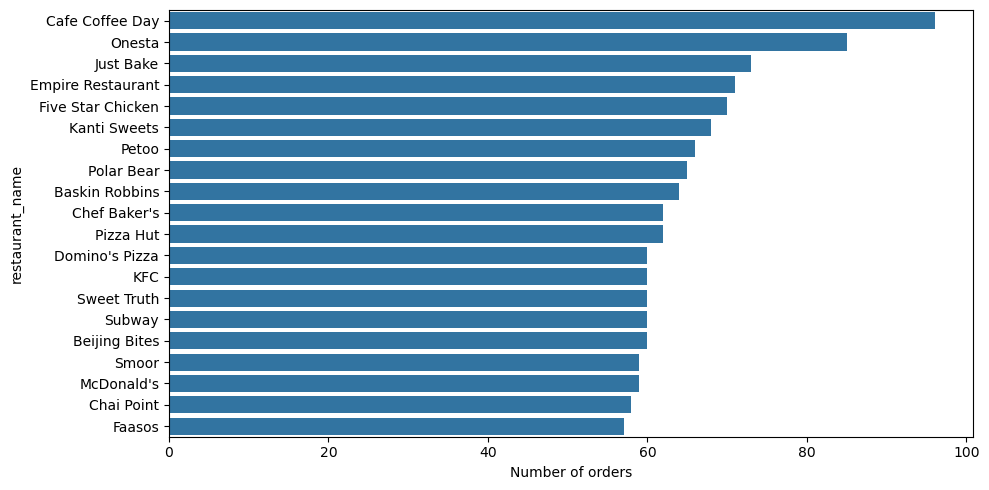

In [67]:
# Most famous restaurants by number of orders or number of restaurants
famous_restaurant = df2['restaurant_name'].value_counts()
print(famous_restaurant[:20])
plt.figure(figsize=(10,5))
sns.barplot(df1['restaurant_name'].value_counts()[:20],orient='h')
plt.xlabel('Number of orders')
plt.tight_layout()
plt.show()

**In object datat type  we can see the most occured categorices**
- `online_order` has more number of online order than offline customers
- `book_table` the customers donot book table they might perfere online mode for home deliver.

online_order
Yes    58.706035
No     41.085136
Name: count, dtype: float64


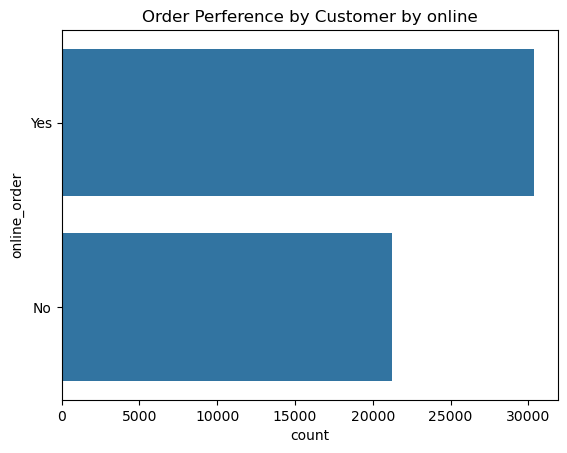

In [68]:
print(df2['online_order'].value_counts()/len(df)*100)
plt.title("Order Perference by Customer by online")
sns.countplot(df2['online_order'])
plt.show()

book_table
No     87.385192
Yes    12.405979
Name: count, dtype: float64


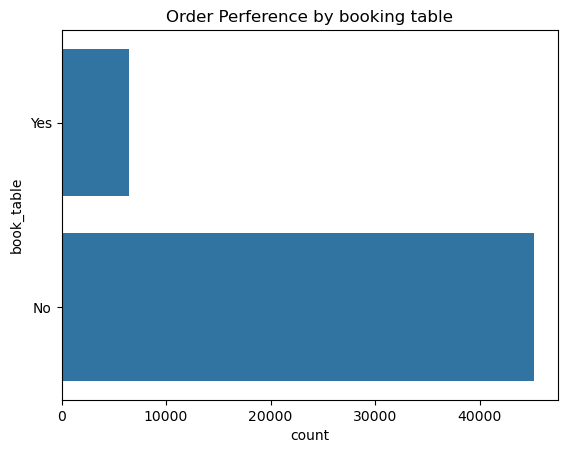

In [69]:
print(df2['book_table'].value_counts()/len(df)*100)
plt.title("Order Perference by booking table")
sns.countplot(df2['book_table'])
plt.show()

In [70]:
df2

,restaurant_name,online_order,book_table,rate,votes,location,restaurant_type,cuisines,cost2people,listed_in_type,listed_in_city
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,Continental,1500.0,Pubs and bars,Whitefield
51713,Vinod Bar And Restaurant,No,No,3.7,0,Whitefield,Bar,Finger Food,600.0,Pubs and bars,Whitefield
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.7,0,Whitefield,Bar,Finger Food,2000.0,Pubs and bars,Whitefield
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,Finger Food,2500.0,Pubs and bars,Whitefield


average rating: 3.700114321145537
median rating: 3.7
mode rating: 3.7


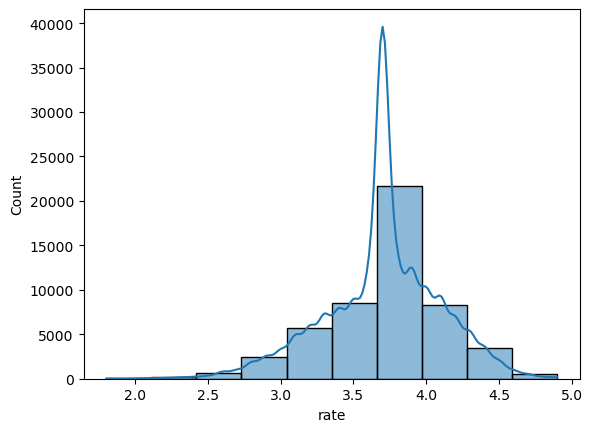

In [71]:
sns.histplot(df2['rate'],bins=10,kde=True) # try 100 bins see detailed, 10 smoonth curve and distribution
print("average rating:",np.mean(df2['rate']))
print("median rating:",np.median(df2['rate']))
print("mode rating:",df2['rate'].mode()[0])
plt.show()

**The customer have positively rated the restaurants as we can see that rate distribution the average, median and mode has same rating which shows normally distributed behaviour majority of rating of restaurant lie between 2.8 to 4.6 shows highly positive, few resturants are low rated from 1.8 to 2.8 and very few restaurants are rated above 4.6. The majority of restuarnts are rated as 3.7**

In [72]:
df2['rate'].value_counts(normalize=True)*100

rate
3.7    26.803465
3.9     7.686644
3.8     7.498692
3.6     6.415548
4.0     6.161716
4.1     5.700556
3.5     5.388595
3.4     4.789862
3.3     4.466275
4.2     4.222132
3.2     3.617586
4.3     3.266872
3.1     3.024666
4.4     2.203104
3.0     1.980275
2.9     1.552055
4.5     1.265283
2.8     1.162588
2.7     0.594857
4.6     0.579356
2.6     0.503788
4.7     0.323587
2.5     0.195702
2.4     0.135635
4.8     0.127885
4.9     0.106571
2.3     0.098820
2.2     0.050379
2.1     0.046504
2.0     0.021314
1.8     0.009688
Name: proportion, dtype: float64

In [73]:
# we can catgeorize these rating into low rated, high rated and mid rated restaurants
df2['rating_bins'] = pd.cut(df2['rate'],bins=3)

C:\Users\Galib\AppData\Local\Temp\ipykernel_8736\1240822155.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['rating_bins'] = pd.cut(df2['rate'],bins=3)


In [74]:
df2['rating_category'] = pd.cut(df2['rate'],bins=3,labels=['low_rated','mid_rated','high_rated'])

C:\Users\Galib\AppData\Local\Temp\ipykernel_8736\3034955898.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['rating_category'] = pd.cut(df2['rate'],bins=3,labels=['low_rated','mid_rated','high_rated'])


In [75]:
rating_category = df2[['rating_category','rating_bins']].value_counts(normalize=True).reset_index(name='pct')
rating_category

,rating_category,rating_bins,pct
0,mid_rated,"(2.833, 3.867]",0.655370
1,high_rated,"(3.867, 4.9]",0.316437
2,low_rated,"(1.797, 2.833]",0.028193


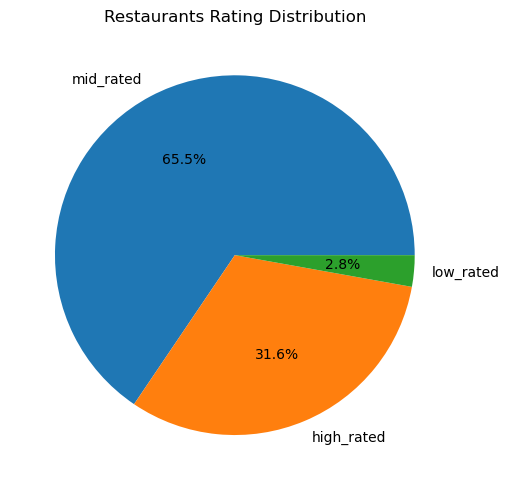

In [76]:
plt.figure(figsize=(10,5))
plt.title("Restaurants Rating Distribution")
plt.pie(rating_category.pct,labels=rating_category.rating_category,autopct="%1.1f%%")
plt.tight_layout()
plt.show()

In [77]:
df2

,restaurant_name,online_order,book_table,rate,votes,location,restaurant_type,cuisines,cost2people,listed_in_type,listed_in_city,rating_bins,rating_category
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari,"(3.867, 4.9]",high_rated
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari,"(3.867, 4.9]",high_rated
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari,"(2.833, 3.867]",mid_rated
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari,"(2.833, 3.867]",mid_rated
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari,"(2.833, 3.867]",mid_rated
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,Continental,1500.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated
51713,Vinod Bar And Restaurant,No,No,3.7,0,Whitefield,Bar,Finger Food,600.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.7,0,Whitefield,Bar,Finger Food,2000.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,Finger Food,2500.0,Pubs and bars,Whitefield,"(3.867, 4.9]",high_rated


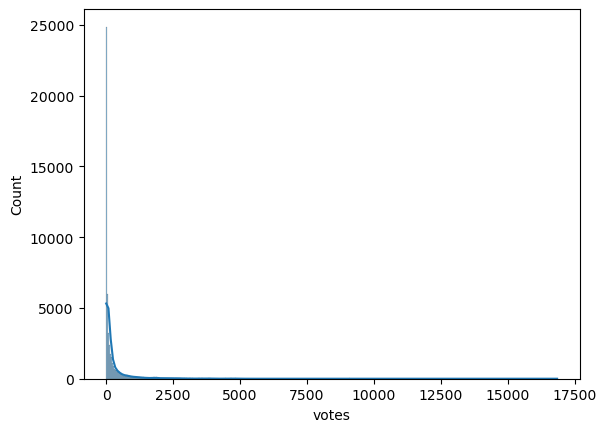

In [78]:
sns.histplot(df2['votes'],kde=True)
plt.show()

**As we can see the distribution is highly right skewed and Most of resturants are voted under 1000 votes whereas fewer and fewer restuarnts are low voted we need cross check with other factors like what kind of resturants are voted fewer and which are highly voted. majority of customers has zero voted means customer donot perfer to vote the resturants or there might be other reasons we need cross feedback this**

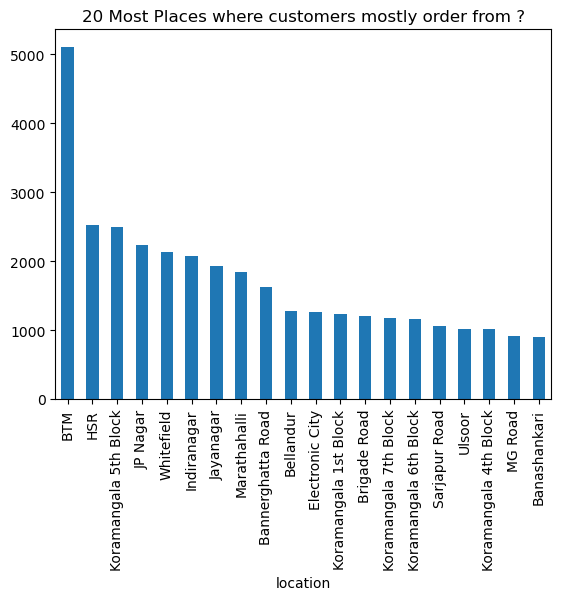

In [79]:
# places from where customer mostly order from ?
plt.title("20 Most Places where customers mostly order from ?")
df2['location'].value_counts()[:20].plot(kind='bar')
plt.show()

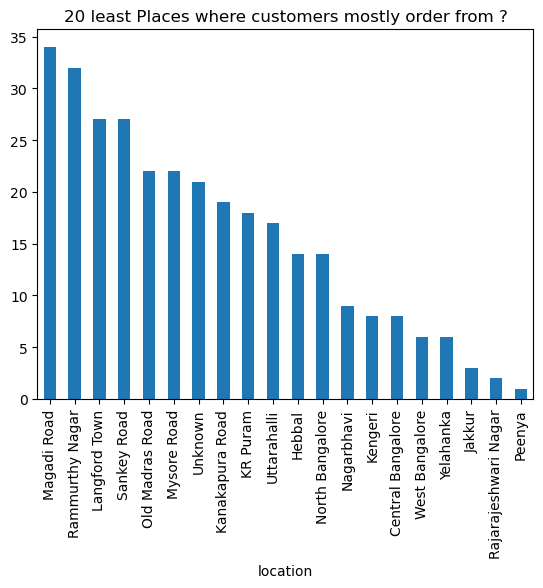

In [80]:
plt.title("20 least Places where customers mostly order from ?")
df2['location'].value_counts()[-20:].plot(kind='bar')
plt.show()

restaurant_type
Quick Bites                   19096
Casual Dining                 10309
Cafe                           3727
Delivery                       2600
Dessert Parlor                 2260
Takeaway, Delivery             2031
Casual Dining, Bar             1148
Bakery                         1140
Beverage Shop                   865
Bar                             697
Food Court                      621
Sweet Shop                      468
Bar, Casual Dining              420
Lounge                          395
Pub                             355
Fine Dining                     345
Casual Dining, Cafe             319
Beverage Shop, Quick Bites      298
Bakery, Quick Bites             289
Mess                            267
Name: count, dtype: int64


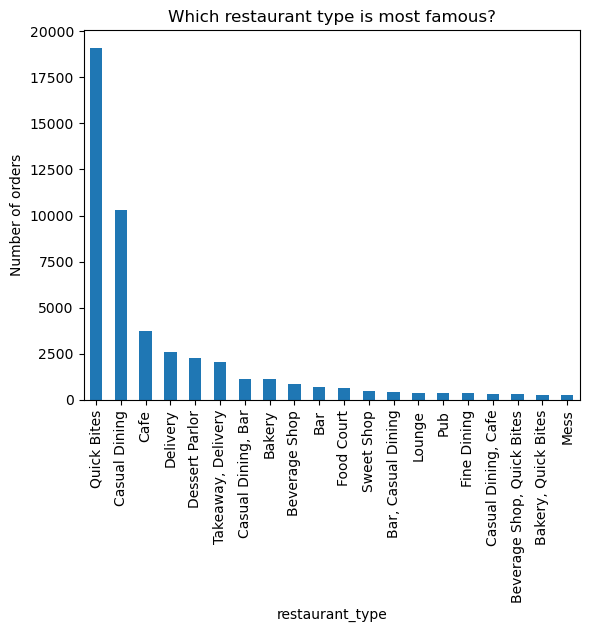

In [81]:
# most famous resturant type which has more number of ordered as data says
# which restaruant type is most famous?
plt.title('Which restaurant type is most famous?')  
df2['restaurant_type'].value_counts()[:20].plot(kind='bar')
print(df2['restaurant_type'].value_counts()[:20])
plt.ylabel("Number of orders")
plt.show()

In [82]:
# is this restuarants order data resturants are bounded with ethics, traditional meals or other recipes 
# Jalsa have casual dining lets see what Jalsa offers? so it bound one theme is casual dining
df2[df2['restaurant_name']=='Jalsa'][['restaurant_name','restaurant_type']].value_counts()

restaurant_name  restaurant_type
Jalsa            Casual Dining      11
Name: count, dtype: int64

In [83]:
df2[df2['restaurant_name']=='Spice Elephant'][['restaurant_name','restaurant_type']].value_counts()

restaurant_name  restaurant_type
Spice Elephant   Casual Dining      4
Name: count, dtype: int64

In [84]:
df2[df2['restaurant_name']=='San Churro Cafe'][['restaurant_name','restaurant_type']].value_counts()

restaurant_name  restaurant_type    
San Churro Cafe  Cafe, Casual Dining    11
Name: count, dtype: int64

cuisines
North Indian                           2907
North Indian, Chinese                  2381
South Indian                           1826
Biryani                                 915
Bakery, Desserts                        910
Fast Food                               801
Desserts                                760
Cafe                                    755
South Indian, North Indian, Chinese     726
Bakery                                  651
Chinese                                 554
Ice Cream, Desserts                     416
Chinese, North Indian                   415
Mithai, Street Food                     372
Desserts, Ice Cream                     353
North Indian, Chinese, Biryani          351
South Indian, North Indian              343
North Indian, South Indian              342
North Indian, South Indian, Chinese     305
Beverages                               301
Name: count, dtype: int64


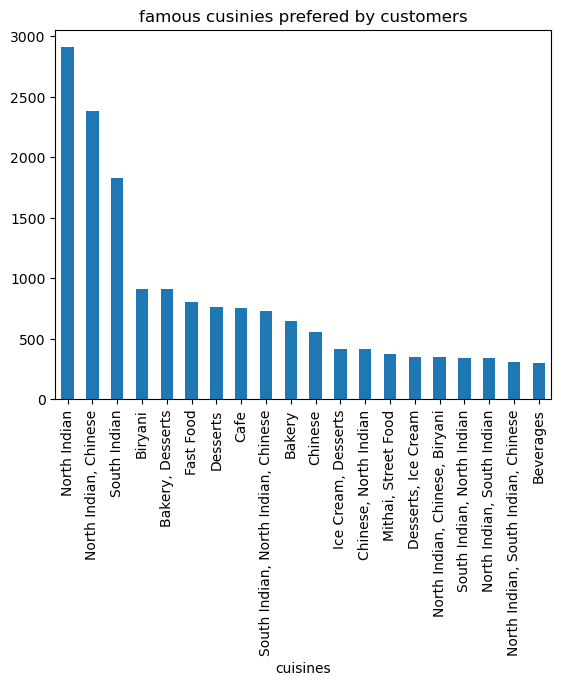

In [85]:
# famous cusinies prefered by customers
# we thought of fast food will be more prefered due to outting but we are wroing
print(df2['cuisines'].value_counts()[:20])
plt.title("famous cusinies prefered by customers")
df2['cuisines'].value_counts()[:20].plot(kind='bar')
plt.show()

In [86]:
# most famous cusinies by restaurant types
df2[df2['cuisines']=='North Indian, Chinese'][['restaurant_type','cuisines']].value_counts()

restaurant_type          cuisines             
Quick Bites              North Indian, Chinese    1256
Casual Dining            North Indian, Chinese     711
Delivery                 North Indian, Chinese     165
Bar                      North Indian, Chinese      88
Takeaway, Delivery       North Indian, Chinese      65
Pub                      North Indian, Chinese      34
Unknown                  North Indian, Chinese      24
Casual Dining, Bar       North Indian, Chinese      21
Bar, Casual Dining       North Indian, Chinese       8
Club                     North Indian, Chinese       4
Food Court, Quick Bites  North Indian, Chinese       2
Pub, Casual Dining       North Indian, Chinese       2
Food Truck               North Indian, Chinese       1
Name: count, dtype: int64

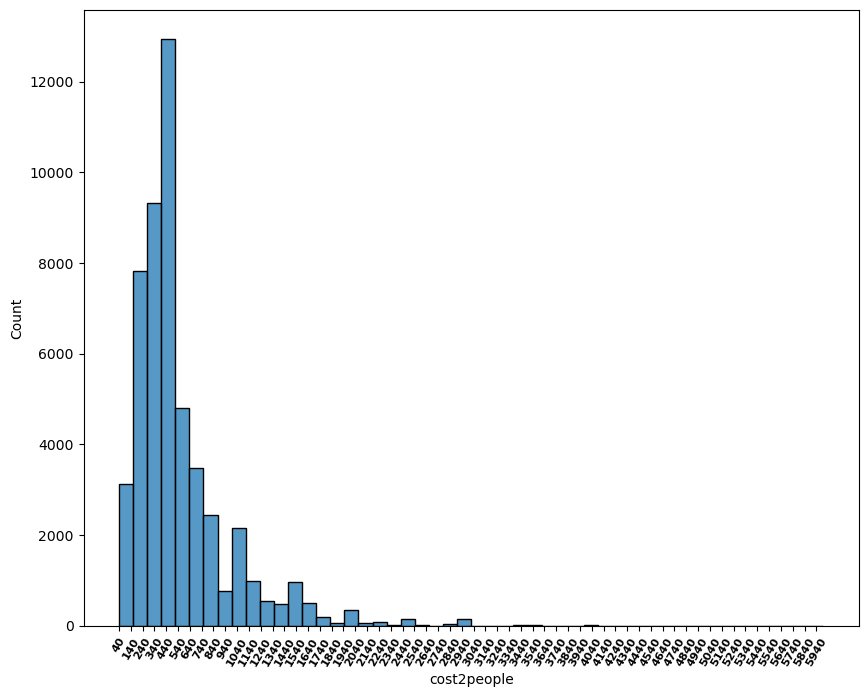

In [87]:
# most resturants order by cost per two people cost friendly cusinies, mid costly cusinies and expensive cusinies
plt.figure(figsize=(10,8))
sns.histplot(df2['cost2people'],bins=50)
plt.xticks(np.arange(int(df2['cost2people'].min()),int(df2['cost2people'].max()),100),rotation=60,fontsize=8,fontweight='bold')
plt.show()

**Right skewed distribution**
- majority of customers perfere lower price cuisines ranging from 40 rupees to 840 rupees per two person.
- few number of customers order cuisines priced from 2040 to to 5940 rupees
- Also most customers order price ranges from 840 to 2040 where we can see pike at price 1040 majority can affored it or price does not matter for quality of this cuisines and similar see at 1540.
- we can interpet the cost for two people with other factors to get more understanding of restaurants.

In [88]:
df2[(df2['cost2people']==40)&(df2['cost2people']<140)][['restaurant_name','restaurant_type','cuisines','cost2people']]

,restaurant_name,restaurant_type,cuisines,cost2people
5270,Srinidhi Sagar Food Line,Quick Bites,"South Indian, North Indian, Chinese",40.0
12232,Srinidhi Sagar Food Line,Quick Bites,"South Indian, North Indian, Chinese",40.0
14819,Srinidhi Sagar Food Line,Quick Bites,"South Indian, North Indian, Chinese",40.0
17773,Srinidhi Sagar,Quick Bites,"South Indian, North Indian, Chinese",40.0
18891,Srinidhi Sagar Food Line,Quick Bites,"South Indian, North Indian, Chinese",40.0
27091,Srinidhi Sagar Deluxe,Quick Bites,"South Indian, North Indian, Chinese",40.0
29785,Srinidhi Sagar Deluxe,Quick Bites,"South Indian, North Indian, Chinese",40.0
32485,Srinidhi Sagar,Quick Bites,"South Indian, North Indian, Chinese",40.0


In [89]:
expensive_restaurants = df2.groupby('restaurant_name')['cost2people'].mean().sort_values(ascending=False)[:20]
print(expensive_restaurants)

restaurant_name
Le Cirque Signature - The Leela Palace                                                      6000.0
Royal Afghan - ITC Windsor                                                                  5000.0
Malties - Radisson Blu                                                                      4500.0
La Brasserie - Le Meridien                                                                  4100.0
Grill 99 - The Ritz-Carlton                                                                 4000.0
Dakshin - ITC Windsor                                                                       4000.0
Alba - JW Marriott Bengaluru                                                                4000.0
Riwaz - The Ritz-Carlton                                                                    4000.0
Edo Restaurant & Bar - ITC Gardenia                                                         4000.0
Jamavar - The Leela Palace                                                                  4

In [90]:
costfriendly_restaurants = df2.groupby('restaurant_name')['cost2people'].mean().sort_values(ascending=False)[-20:]
print(costfriendly_restaurants)

restaurant_name
Nandini Dosa Camp                  100.000000
Nandishwara Lunch Home             100.000000
Chai Makhani                       100.000000
Chai Kraft                         100.000000
Cane Hut                           100.000000
New Bangarpet Snacks               100.000000
Vishwa Brahmin's Cafe              100.000000
Chaiwala                           100.000000
Cane Recipes                       100.000000
Cane-O-La                          100.000000
Cha-Cha Cha-Chi                    100.000000
Shree Ganesh Fruit Juice Centre     90.000000
Dosa Cafe                           80.000000
Dtink Lab                           80.000000
Savera Cafe                         71.428571
Namaste                             70.000000
Nellore Dosa Camp                   70.000000
Funky Food                          60.000000
Bread & Better                      50.000000
Srinidhi Sagar Deluxe               40.000000
Name: cost2people, dtype: float64


In [91]:
df2['listed_in_type'].unique()

array(['Buffet', 'Cafes', 'Delivery', 'Desserts', 'Dine-out',
       'Drinks & nightlife', 'Pubs and bars'], dtype=object)

**Total revenue and Total Order Quantity**

- restaurants name having online order and how much total revenue generated
- restaurants name having booking table service online and how much they revenue generated
- which restaurant type generates more reveuene listing only top 10 ones?
- which restaurant listed catgeory type has highest revenue ie buffet?
- which cuisines is most famous and how much it cost in different locations (listed city region not location)?
- which restaurants has high rated and what is its cost per 2 people?
- which listed cusinies category type ie buffet has high revenue list each catgeories 3 to 5 cusinies?
- which are highest voted restuarants and their cost2people?
- which cusinies have highest average cost, online order or offline high, book table ?
- rating category, listed in type and votes high and low votes
- restaurant having high order quantity by online order, book table?
- restaurant having high votes , rating , cost ?
- listed in type having high votes , rating , cost ?

In [92]:
total_revenue = df2['cost2people'].sum()
total_order_qty = df2['cost2people'].count()
avg_rating = df2["rate"].mean()
avg_votes = df2['votes'].mean()
avg_cost = df2['cost2people'].mean()

print(total_revenue,total_order_qty,avg_rating,avg_votes)
metrics = pd.DataFrame(data={"total_revenue":total_revenue,\
                             "total_order_qty":total_order_qty,\
                             "avg_rating":avg_rating,\
                             "avg_votes":avg_votes,\
                             "avg_cost":avg_cost},\
                             index=[0])
metrics

28651745.0 51609 3.700114321145537 283.28336142920807


,total_revenue,total_order_qty,avg_rating,avg_votes,avg_cost
0,28651745.0,51609,3.700114,283.283361,555.169544


In [93]:
df2

,restaurant_name,online_order,book_table,rate,votes,location,restaurant_type,cuisines,cost2people,listed_in_type,listed_in_city,rating_bins,rating_category
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari,"(3.867, 4.9]",high_rated
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari,"(3.867, 4.9]",high_rated
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari,"(2.833, 3.867]",mid_rated
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari,"(2.833, 3.867]",mid_rated
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari,"(2.833, 3.867]",mid_rated
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,Continental,1500.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated
51713,Vinod Bar And Restaurant,No,No,3.7,0,Whitefield,Bar,Finger Food,600.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.7,0,Whitefield,Bar,Finger Food,2000.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,Finger Food,2500.0,Pubs and bars,Whitefield,"(3.867, 4.9]",high_rated


In [94]:
# restaurant type by total revenue high
rest_type_having_high_revenue = df2.groupby('restaurant_type')['cost2people'].sum().sort_values(ascending=False)[:10].reset_index(name='total_revenue')
rest_type_having_high_revenue

,restaurant_type,total_revenue
0,Casual Dining,8136570.0
1,Quick Bites,6081780.0
2,Cafe,2308425.0
3,"Casual Dining, Bar",1422140.0
4,Delivery,1127694.0
5,Fine Dining,934800.0
6,Bar,875555.0
7,"Takeaway, Delivery",799911.0
8,Dessert Parlor,755430.0
9,Lounge,669550.0


In [95]:
### highest reveneu generating restaurants having order quatity how much?
high_revenue_high_order_rest = df2.groupby('restaurant_type')[['cost2people','restaurant_type']].agg({'cost2people':'sum','restaurant_type':'count'}).sort_values(by='cost2people',ascending=False)[:10]
high_revenue_high_order_rest.columns = ['total_revenue','total_order_qty']
high_revenue_high_order_rest

,total_revenue,total_order_qty
restaurant_type,,
Casual Dining,8136570.0,10309
Quick Bites,6081780.0,19096
Cafe,2308425.0,3727
"Casual Dining, Bar",1422140.0,1148
Delivery,1127694.0,2600
Fine Dining,934800.0,345
Bar,875555.0,697
"Takeaway, Delivery",799911.0,2031
Dessert Parlor,755430.0,2260


In [96]:
high_revenue_high_order_rest.index

Index(['Casual Dining', 'Quick Bites', 'Cafe', 'Casual Dining, Bar',
       'Delivery', 'Fine Dining', 'Bar', 'Takeaway, Delivery',
       'Dessert Parlor', 'Lounge'],
      dtype='object', name='restaurant_type')

In [97]:
# lets cross check whether order qty correct for `bar` restaurant type
df2[df2['restaurant_type']=='Bar']

,restaurant_name,online_order,book_table,rate,votes,location,restaurant_type,cuisines,cost2people,listed_in_type,listed_in_city,rating_bins,rating_category
95,Vi Ra's Bar and Restaurant,No,No,3.3,62,Banashankari,Bar,"South Indian, North Indian, Chinese",800.0,Delivery,Banashankari,"(2.833, 3.867]",mid_rated
119,K27 - The Pub,No,No,3.1,30,Banashankari,Bar,"Chinese, North Indian",1000.0,Delivery,Banashankari,"(2.833, 3.867]",mid_rated
146,Darbar,No,No,3.0,98,Banashankari,Bar,"North Indian, Chinese",800.0,Delivery,Banashankari,"(2.833, 3.867]",mid_rated
337,South Point Pub,Yes,No,3.4,11,Basavanagudi,Bar,"North Indian, Seafood, Chinese",800.0,Delivery,Banashankari,"(2.833, 3.867]",mid_rated
597,Vi Ra's Bar and Restaurant,No,No,3.3,62,Banashankari,Bar,"South Indian, North Indian, Chinese",800.0,Dine-out,Banashankari,"(2.833, 3.867]",mid_rated
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51710,Topsy Turvey,No,No,3.7,0,Whitefield,Bar,Finger Food,900.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,Continental,1500.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated
51713,Vinod Bar And Restaurant,No,No,3.7,0,Whitefield,Bar,Finger Food,600.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.7,0,Whitefield,Bar,Finger Food,2000.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated


In [98]:
# business understanding
# bars relation with other factors 
# does restaurants sell beverges online there are bars 100:500 enjoy home or whereever
# does restaurants has book table for bars yes there are half number of bars time convinent
# bars avg rating 3.73
# bars top 5 location highest sells which location has most bars, reveneue , votes, high rating 
# which bars provide which cusinies what is there cost high low , rating
# where these orders are listed in which city nearby or orgini city
# overall revenue by listed city ordered
# restauarants/bars which high reveneue and least revenue , ordered qty 
'''location
Koramangala 4th Block         67
Koramangala 6th Block         56
BTM                           49
Richmond Road                 44
Residency Road                39'''
# bars top 5 location highest sells with online order and book table


'location\nKoramangala 4th Block         67\nKoramangala 6th Block         56\nBTM                           49\nRichmond Road                 44\nResidency Road                39'

  online_order  has_online_order
0           No               594
1          Yes               103


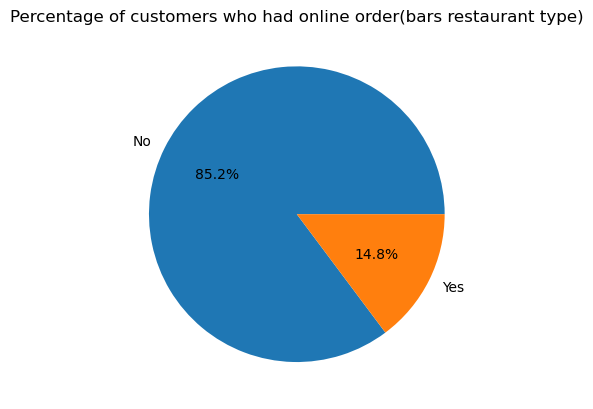

In [99]:
bar_rest = df2[df2['restaurant_type']=='Bar']

# bar restaurant type does restaurant sell beverges online ?
online_order = bar_rest['online_order'].value_counts().reset_index(name='has_online_order')
print(online_order)

# does restaurants has book table for bars yes there are half number of bars time convinent
bar_rest['book_table'].value_counts()
plt.title("Percentage of customers who had online order(bars restaurant type)")
plt.pie(online_order.has_online_order,labels=online_order.online_order,autopct="%1.1f%%")
plt.show()

  book_table  had_book_table
0         No             459
1        Yes             238


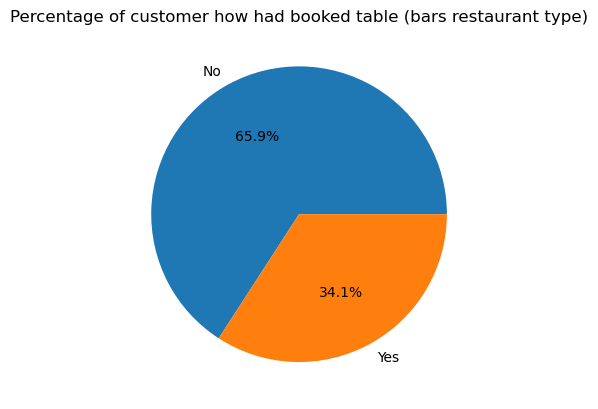

In [100]:
# does restaurants has book table for bars yes there are half number of bars time convinent
book_table = bar_rest['book_table'].value_counts().reset_index(name='had_book_table')
plt.title("Percentage of customer how had booked table (bars restaurant type)")
plt.pie(book_table['had_book_table'],labels=book_table['book_table'],autopct="%1.1f%%")
print(book_table)
plt.show()

          location  number of bars
0              BTM              49
1  Electronic City              25
2     Banashankari              23
3           Domlur              17
4  Cunningham Road              13
5     Basavanagudi              11
6        Bellandur              11
7     Brigade Road              10
8        Banaswadi               9
9     Bommanahalli               4


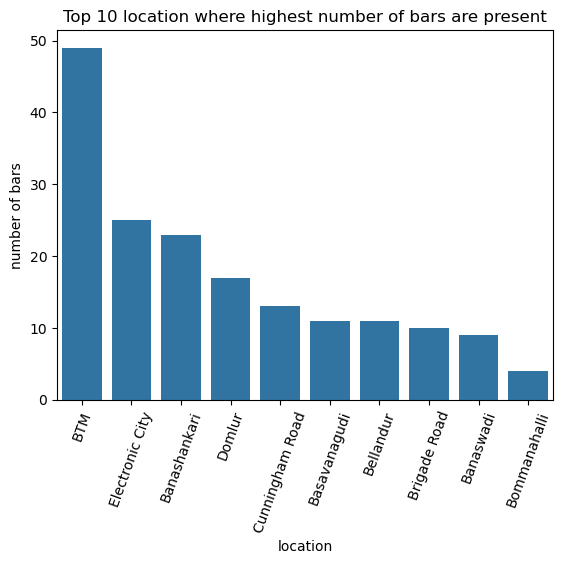

In [101]:
# bars top 10 location highest sells which location has most bars, reveneue , votes, high rating 
top_10_bars_pop = bar_rest.groupby('location')['location'].count()[:10].sort_values(ascending=False).reset_index(name='number of bars')
plt.title("Top 10 location where highest number of bars are present")
print(top_10_bars_pop)
sns.barplot(y=top_10_bars_pop["number of bars"],x=top_10_bars_pop['location'])
plt.tick_params(axis='x',rotation=70)
plt.show()

          location  Total revenue
0              BTM        54000.0
1  Electronic City        33000.0
2           Domlur        21800.0
3     Brigade Road        20000.0
4     Banashankari        19600.0
5  Cunningham Road        19500.0
6     Basavanagudi        17200.0
7        Bellandur        16500.0
8        Banaswadi        11300.0
9     Bommanahalli         6000.0


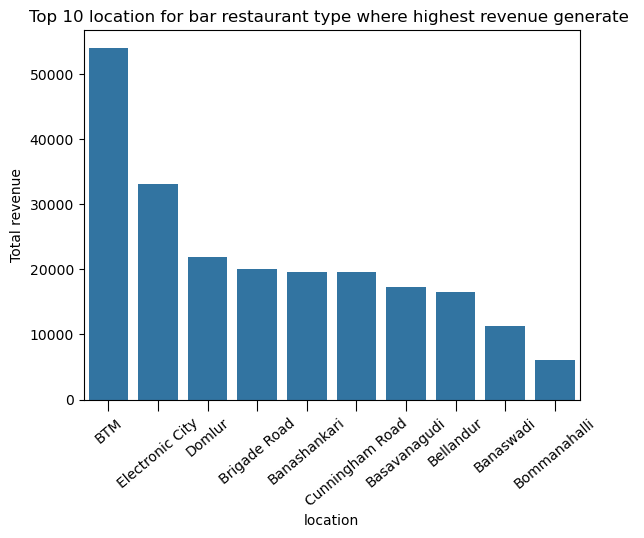

In [102]:
# bars top 10 location highest sells which location has most bars, reveneue , votes, high rating 

top_10_bars_revenue = bar_rest.groupby('location')['cost2people'].sum()[:10].sort_values(ascending=False).reset_index(name='Total revenue')
print(top_10_bars_revenue)
plt.title("Top 10 location for bar restaurant type where highest revenue generate ")
sns.barplot(x=top_10_bars_revenue.location,y=top_10_bars_revenue['Total revenue'])
plt.tick_params(axis='x',rotation=40,size=8)
plt.show()

In [103]:
top_10_bars_rate_votes = bar_rest.groupby('location')[['rate','votes']].mean().sort_values(by='rate',ascending=False)[:10]
top_10_bars_rate_votes

,rate,votes
location,,
Koramangala 5th Block,4.505405,3479.513514
Nagawara,4.500000,755.000000
"ITPL Main Road, Whitefield",4.300000,236.000000
Koramangala 3rd Block,4.100000,759.076923
Sankey Road,4.100000,187.000000
Brigade Road,4.070000,1218.000000
Wilson Garden,4.000000,138.400000
Old Airport Road,3.990000,276.600000
Kalyan Nagar,3.940000,301.400000


In [104]:
# top 20 cusinies 
top_20_cusinies_bar = bar_rest.groupby('cuisines')[['cuisines','cost2people']].agg({'cuisines':'count','cost2people':'sum'}).sort_values(by='cost2people',ascending=False)
top_20_cusinies_bar.columns = ['total orders','total revenue']
top_20_cusinies_bar[:20]

,total orders,total revenue
cuisines,,
Finger Food,113,141605.0
"North Indian, Chinese",88,101300.0
"Continental, Chinese",34,47200.0
"Finger Food, North Indian, Chinese",35,40700.0
"Finger Food, Fast Food, Continental",18,39600.0
"Finger Food, Continental",23,36600.0
"Finger Food, North Indian",13,32500.0
"South Indian, North Indian",29,28100.0
"Finger Food, Mediterranean, North Indian",13,26000.0


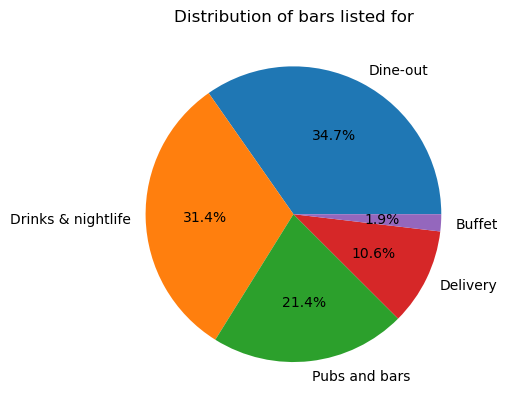

In [105]:
# bar restauarnt type where these transcations are listed in type
bar_lsited_in_type_distr = bar_rest['listed_in_type'].value_counts().reset_index(name='number_of_orders')
plt.title("Distribution of bars listed for")
plt.pie(bar_lsited_in_type_distr.number_of_orders,labels=bar_lsited_in_type_distr.listed_in_type,autopct='%1.1f%%')
plt.show()

In [ ]:
# overall where the bars restaurant type were listed in which city similar to location
# but does not provide details of specific location which is present in location column 
# listed location and order location
bar_rest['listed_in_city'].value_counts()

listed_in_city
Koramangala 7th Block    64
Koramangala 5th Block    63
BTM                      47
Brigade Road             42
Church Street            42
Koramangala 4th Block    40
Koramangala 6th Block    39
MG Road                  38
Lavelle Road             37
Residency Road           32
Indiranagar              32
Electronic City          25
Old Airport Road         22
Whitefield               19
Kammanahalli             15
Jayanagar                15
Kalyan Nagar             13
HSR                      12
Malleshwaram             12
Banashankari             12
Marathahalli             11
Basavanagudi             11
Frazer Town              10
Bellandur                 9
Rajajinagar               9
Sarjapur Road             9
JP Nagar                  7
Brookefield               4
New BEL Road              4
Bannerghatta Road         2
Name: count, dtype: int64

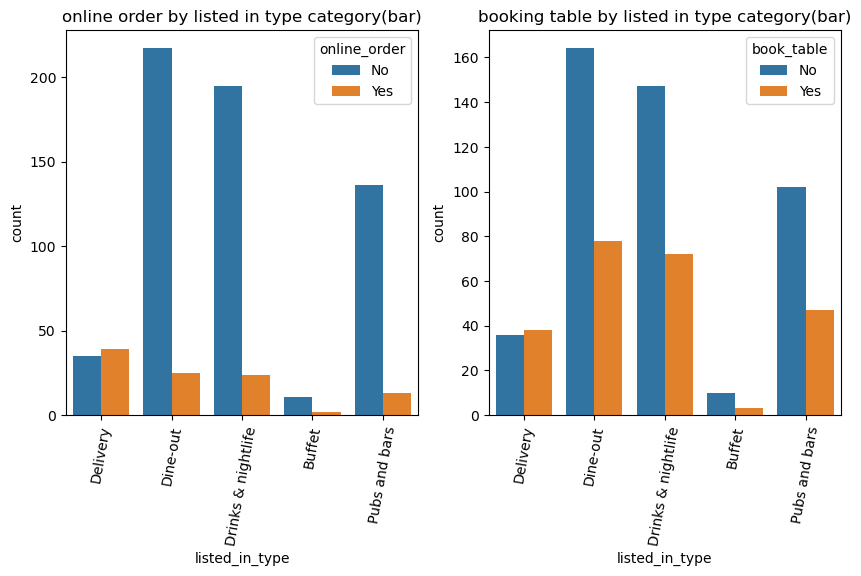

In [107]:
# listed in type with online order perference
fig,ax = plt.subplots(1,2,figsize=(10,5))

ax[0].set_title("online order by listed in type category(bar)")
sns.countplot(data=bar_rest,x='listed_in_type',hue='online_order',ax=ax[0])

ax[1].set_title("booking table by listed in type category(bar)")
sns.countplot(data=bar_rest,x='listed_in_type',hue='book_table',ax=ax[1])
ax[0].tick_params(axis='x',rotation=80)
ax[1].tick_params(axis='x',rotation=80)

plt.show()

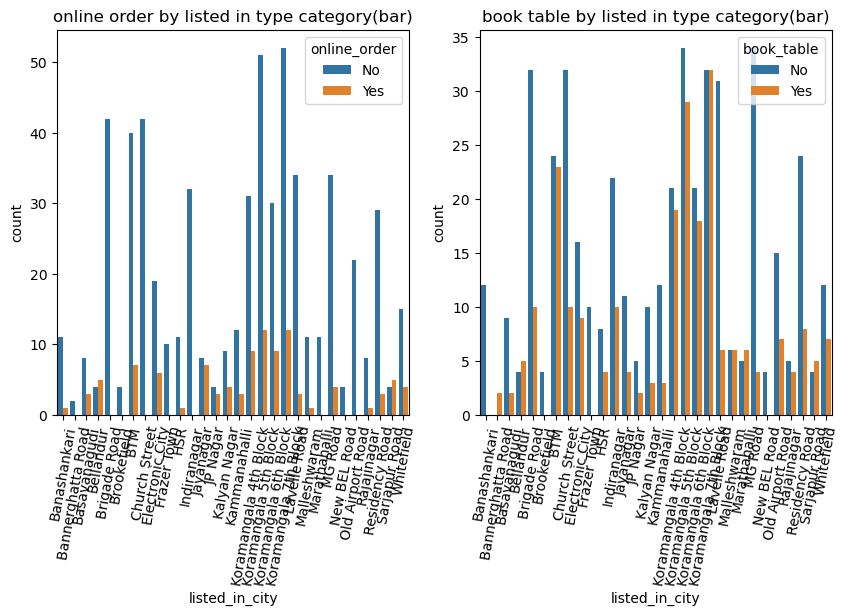

In [108]:
# listed in city by online order
fig,ax = plt.subplots(1,2,figsize=(10,5))

ax[0].set_title("online order by listed in type category(bar)")

sns.countplot(data=bar_rest,x='listed_in_city',hue='online_order',ax=ax[0])
ax[0].tick_params(axis='x',rotation=80)


ax[1].set_title("book table by listed in type category(bar)")

sns.countplot(data=bar_rest,x='listed_in_city',hue='book_table',ax=ax[1])
ax[1].tick_params(axis='x',rotation=80)

plt.show()

In [109]:
bar_rest

,restaurant_name,online_order,book_table,rate,votes,location,restaurant_type,cuisines,cost2people,listed_in_type,listed_in_city,rating_bins,rating_category
95,Vi Ra's Bar and Restaurant,No,No,3.3,62,Banashankari,Bar,"South Indian, North Indian, Chinese",800.0,Delivery,Banashankari,"(2.833, 3.867]",mid_rated
119,K27 - The Pub,No,No,3.1,30,Banashankari,Bar,"Chinese, North Indian",1000.0,Delivery,Banashankari,"(2.833, 3.867]",mid_rated
146,Darbar,No,No,3.0,98,Banashankari,Bar,"North Indian, Chinese",800.0,Delivery,Banashankari,"(2.833, 3.867]",mid_rated
337,South Point Pub,Yes,No,3.4,11,Basavanagudi,Bar,"North Indian, Seafood, Chinese",800.0,Delivery,Banashankari,"(2.833, 3.867]",mid_rated
597,Vi Ra's Bar and Restaurant,No,No,3.3,62,Banashankari,Bar,"South Indian, North Indian, Chinese",800.0,Dine-out,Banashankari,"(2.833, 3.867]",mid_rated
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51710,Topsy Turvey,No,No,3.7,0,Whitefield,Bar,Finger Food,900.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,Continental,1500.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated
51713,Vinod Bar And Restaurant,No,No,3.7,0,Whitefield,Bar,Finger Food,600.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.7,0,Whitefield,Bar,Finger Food,2000.0,Pubs and bars,Whitefield,"(2.833, 3.867]",mid_rated


In [110]:
loc_list_in_city = bar_rest[['listed_in_city','location']].value_counts().reset_index(name='Number_of_orders')
loc_list_in_city[loc_list_in_city['listed_in_city']=='Koramangala 6th Block']

,listed_in_city,location,Number_of_orders
12,Koramangala 6th Block,Koramangala 4th Block,11
13,Koramangala 6th Block,Koramangala 6th Block,11
34,Koramangala 6th Block,Koramangala 5th Block,6
46,Koramangala 6th Block,BTM,5
111,Koramangala 6th Block,Koramangala 3rd Block,2
125,Koramangala 6th Block,Hosur Road,2
129,Koramangala 6th Block,Koramangala 1st Block,1
131,Koramangala 6th Block,HSR,1


**check for location same for all restuarants nor listed order which is listed in city for eg kormangala 6th Block and restaurant location 
 same listed in city and location listed in city like listed order and location can be resturants location or vice versa**


In [ ]:
# check for location same for all restuarants nor listed order which is listed in city for eg kormangala 6th Block and restaurant location 
# same listed in city and location listed in city like listed order and location can be resturants location or vice versa
loc_list_in_city = bar_rest[['restaurant_name','listed_in_city','location']].value_counts().reset_index(name='Number_of_orders')
loc_list_in_city[loc_list_in_city['listed_in_city']=='Koramangala 6th Block']

,restaurant_name,listed_in_city,location,Number_of_orders
110,Fill N Chill Resto Bar & Pub,Koramangala 6th Block,Koramangala 4th Block,3
114,Banana Beach Bar,Koramangala 6th Block,Koramangala 6th Block,3
126,Crawl Street,Koramangala 6th Block,Koramangala 5th Block,3
139,House Of Commons,Koramangala 6th Block,Koramangala 5th Block,3
148,Invitation Bar & Restaurant,Koramangala 6th Block,BTM,3
165,Zanzibar - Davanam Sarovar Portico Suites,Koramangala 6th Block,BTM,2
172,Sutra Spice-The Resto Bar,Koramangala 6th Block,Koramangala 4th Block,2
176,The Old Fashioned Bar,Koramangala 6th Block,Koramangala 6th Block,2
188,Barcode,Koramangala 6th Block,Koramangala 4th Block,2
201,Fandom at Gilly's Redefined,Koramangala 6th Block,Koramangala 4th Block,2


**we are just assuming or hypothesis for further future analysis this scenario that restaurant listed in city is restaurants location and location is customers location
`A Bar` is a restaurant name where the order was listed in city and to location which is customers location
here listed in city is low cardinality than location.**

In [118]:
rest_loc_by_customer_loc = pd.crosstab(bar_rest['listed_in_city'],bar_rest['location'])
rest_loc_by_customer_loc

location,BTM,Banashankari,Banaswadi,Basavanagudi,Bellandur,Bommanahalli,Brigade Road,Cunningham Road,Domlur,Electronic City,...,Richmond Road,Sankey Road,Seshadripuram,Shanti Nagar,Shivajinagar,St. Marks Road,Ulsoor,Whitefield,Wilson Garden,Yeshwantpur
listed_in_city,,,,,,,,,,,,,,,,,,,,,
BTM,13,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Banashankari,0,11,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bannerghatta Road,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Basavanagudi,0,6,0,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bellandur,0,0,0,0,5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Brigade Road,0,0,0,0,0,0,0,3,0,0,...,10,0,0,3,3,3,5,0,0,0
Brookefield,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
Church Street,0,0,0,0,0,0,0,3,0,0,...,10,0,0,3,3,3,5,0,0,0
Electronic City,0,0,0,0,0,0,0,0,0,25,...,0,0,0,0,0,0,0,0,0,0


In [141]:
# Listed in city which is restuarant loc and location which is customers loc 
location = 'BTM' # this is rest loc and we going to take customer wise number of order from rest loc to customer loc
print(f"Restaurant Location: {location}")
print("Customer location to deliver orders")
Btm_rest_loc_by_custoemr_loc = rest_loc_by_customer_loc.iloc[0,:].reset_index(name="Number_of_order") # here we can understand whether order was listed in rest loc and customer loc same or not or nearby
print(Btm_rest_loc_by_custoemr_loc[:10])
dict_btm = {}
print("**"*50)
for i in zip(Btm_rest_loc_by_custoemr_loc.location,Btm_rest_loc_by_custoemr_loc.Number_of_order):
    if i[1] > 0:
        print(i)
        dict_btm[i[0]]=i[1]

Restaurant Location: BTM
Customer location to deliver orders
          location  Number_of_order
0              BTM               13
1     Banashankari                0
2        Banaswadi                0
3     Basavanagudi                0
4        Bellandur                0
5     Bommanahalli                0
6     Brigade Road                0
7  Cunningham Road                0
8           Domlur                0
9  Electronic City                0
****************************************************************************************************
('BTM', 13)
('HSR', 2)
('Hosur Road', 3)
('JP Nagar', 4)
('Koramangala 3rd Block', 3)
('Koramangala 4th Block', 13)
('Koramangala 5th Block', 8)
('Koramangala 6th Block', 1)


In [155]:
print(dict_btm.keys())

dict_keys(['BTM', 'HSR', 'Hosur Road', 'JP Nagar', 'Koramangala 3rd Block', 'Koramangala 4th Block', 'Koramangala 5th Block', 'Koramangala 6th Block'])


In [160]:
bar_rest[bar_rest['listed_in_city'].isin(dict_btm.keys())].head()

,restaurant_name,online_order,book_table,rate,votes,location,restaurant_type,cuisines,cost2people,listed_in_type,listed_in_city,rating_bins,rating_category
9105,Mockaholic Restro Beer Cafe,Yes,No,3.9,914,JP Nagar,Bar,"North Indian, Chinese, Pizza, BBQ",1000.0,Delivery,BTM,"(3.867, 4.9]",high_rated
9110,Pecos Hideout,No,Yes,4.0,165,BTM,Bar,Finger Food,1100.0,Delivery,BTM,"(3.867, 4.9]",high_rated
9374,Fill N Chill Resto Bar & Pub,Yes,Yes,3.9,597,Koramangala 4th Block,Bar,"Finger Food, North Indian, Chinese",1200.0,Delivery,BTM,"(3.867, 4.9]",high_rated
9422,Crawl Street,Yes,Yes,4.3,2563,Koramangala 5th Block,Bar,"Continental, Finger Food, North Indian, Chinese",1200.0,Delivery,BTM,"(3.867, 4.9]",high_rated
9553,Invitation Bar & Restaurant,No,No,3.0,15,BTM,Bar,North Indian,1000.0,Delivery,BTM,"(2.833, 3.867]",mid_rated


In [148]:
bar_rest[(bar_rest['listed_in_city']=='BTM')&(bar_rest['location']=='BTM')][['online_order','location','listed_in_city']].value_counts()

online_order  location  listed_in_city
No            BTM       BTM               13
Name: count, dtype: int64

In [ ]:
bar_rest[(bar_rest['listed_in_city']=='BTM')&(bar_rest['location'].isin(dict_btm.keys()))][['online_order','location','listed_in_city']].value_counts()

online_order  location               listed_in_city
No            BTM                    BTM               13
              Koramangala 4th Block  BTM               12
              Koramangala 5th Block  BTM                4
Yes           Koramangala 5th Block  BTM                4
No            Hosur Road             BTM                3
              JP Nagar               BTM                3
              Koramangala 3rd Block  BTM                3
              HSR                    BTM                2
Yes           JP Nagar               BTM                1
              Koramangala 4th Block  BTM                1
              Koramangala 6th Block  BTM                1
Name: count, dtype: int64

In [161]:
bar_rest[(bar_rest['listed_in_city']=='BTM')&(bar_rest['location'].isin(dict_btm.keys()))][['book_table','location','listed_in_city']].value_counts()

book_table  location               listed_in_city
No          BTM                    BTM               9
            Koramangala 4th Block  BTM               9
Yes         Koramangala 5th Block  BTM               8
            BTM                    BTM               4
            Koramangala 4th Block  BTM               4
No          Hosur Road             BTM               3
Yes         JP Nagar               BTM               3
            Koramangala 3rd Block  BTM               3
No          HSR                    BTM               2
            JP Nagar               BTM               1
Yes         Koramangala 6th Block  BTM               1
Name: count, dtype: int64

**This was assumption tried interpret**

**Here we can see that number of orders for each customer location from restuarant location `BTM`. It shows whether customer belongs to same location of restuarant**

In [112]:
online_dist_by_bar = df2[df2['restaurant_type']=='Bar'].groupby(['location','online_order'])[['location','online_order']].value_counts().sort_values(ascending=False).reset_index()
online_dist_by_bar

,location,online_order,count
0,Koramangala 4th Block,No,52
1,BTM,No,49
2,Richmond Road,No,44
3,Koramangala 6th Block,No,40
4,Residency Road,No,39
5,Indiranagar,No,24
6,Banashankari,No,23
7,Ulsoor,No,22
8,Marathahalli,No,21
9,Koramangala 5th Block,Yes,19


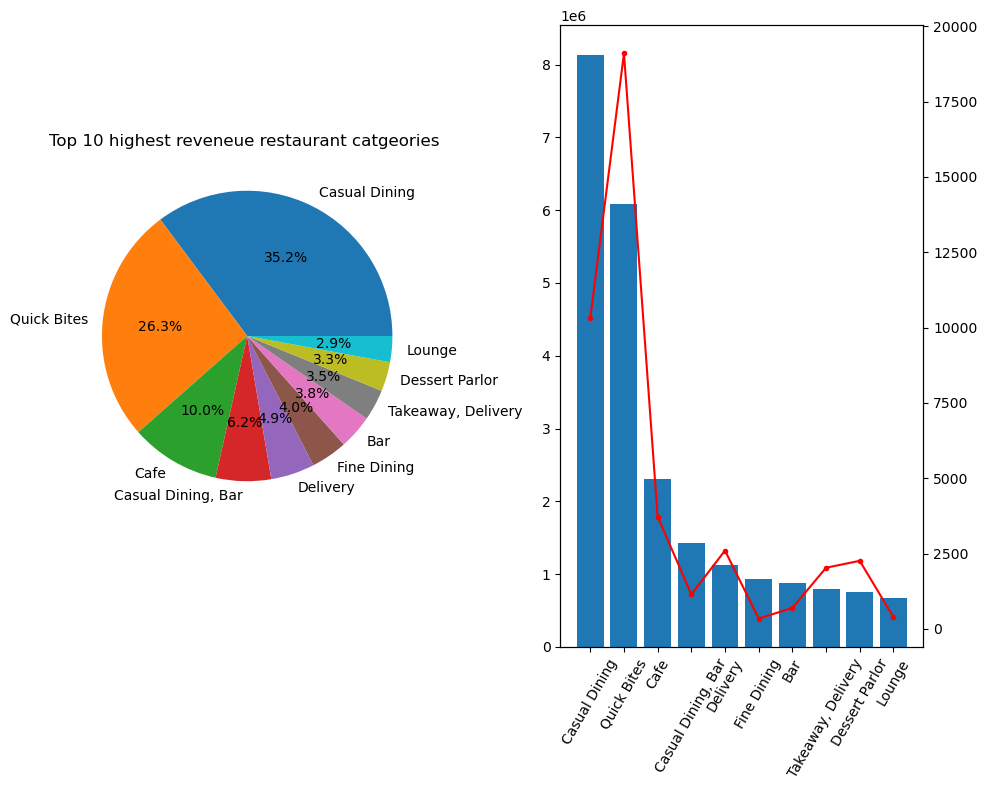

In [113]:
# pie chart
fig,ax = plt.subplots(1,2,figsize=(10,8))
plt.subplots_adjust(wspace=0.4, hspace=0.6)
ax[0].set_title("Top 10 highest reveneue restaurant catgeories ")
ax[0].pie(rest_type_having_high_revenue.total_revenue,labels=rest_type_having_high_revenue.restaurant_type,autopct="%1.1f%%")

ax[1].bar(height=high_revenue_high_order_rest.total_revenue,x=high_revenue_high_order_rest.index)
ax[1].tick_params(axis="x",rotation=60)
ax2 = ax[1].twinx()
ax2.plot(high_revenue_high_order_rest.total_order_qty,color='red',marker='.')

plt.tight_layout()
plt.show()

In [114]:
df2['listed_in_city']

0        Banashankari
1        Banashankari
2        Banashankari
3        Banashankari
4        Banashankari
             ...     
51712      Whitefield
51713      Whitefield
51714      Whitefield
51715      Whitefield
51716      Whitefield
Name: listed_in_city, Length: 51609, dtype: object